# Определение тональности отзывов на банки с помощью одномерной сверточной нейронной сети в TensorFlow

Чтобы запускать и редактировать код, сохраните копию этого ноутбука себе (Файл -> Создать копию на Диске). Свою копию вы сможете изменять и запускать.

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

<a target="_blank" href="https://colab.research.google.com/github/sozykin/dlpython_course/blob/master/rnn/tensorflow/text_classification_gru.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



In [1]:
pip install pymorphy3[fast]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import pymorphy3
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, MaxPooling1D, Conv1D, GlobalMaxPooling1D, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sozyk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sozyk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sozyk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Константы

In [4]:
max_words = 10000
maxlen = 200
random_state = 42

## Загружаем и готовим набор данных

In [5]:
data_path = 'data'

In [6]:
path = Path(data_path)

if not path.exists():
    path.mkdir(parents=True, exist_ok=True)

In [7]:
!curl -s -L -o data/banks.csv "https://www.dropbox.com/scl/fi/mhiwx4plaua183bnuqt5e/train2.csv?rlkey=wv4dalbsutmzu5br9qv5ez21v&dl=1"

In [8]:
banks = pd.read_csv('data/banks.csv', index_col='id');

In [9]:
banks

,text,label
id,,
0,В Альфа-Банке работает замечательная девушка -...,1
1,Оформляя рассрочку в м. Видео в меге тёплый ст...,0
2,Очень порадовала оперативность работы в банке....,1
3,Имела неосторожность оформить потреб. кредит в...,0
4,Небольшая предыстория: Нашел на сайте MDM банк...,0
...,...,...
13994,"О высокой надёжности МКБ, порядочности и добро...",1
13995,"Обслуживаюсь в офисе на Чернореченской 42а, ка...",1
13996,Попала сегодня в очень неприятную ситуацию. Ре...,1


In [10]:
def preprocess(text, stop_words, punctuation_marks, morph):
    tokens = word_tokenize(text.lower())
    preprocessed_text = []
    for token in tokens:
        if token not in punctuation_marks:
            lemma = morph.parse(token)[0].normal_form
            if lemma not in stop_words:
                preprocessed_text.append(lemma)
    return preprocessed_text

In [11]:
punctuation_marks = ['!', ',', '(', ')', ':', '-', '?', '.', '..', '...', '«', '»', ';', '–', '--']
stop_words = stopwords.words("russian")
morph = pymorphy3.MorphAnalyzer()

In [12]:
banks['Preprocessed_texts'] = banks.apply(lambda row: preprocess(row['text'], stop_words, punctuation_marks, morph), axis=1)

In [13]:
banks

,text,label,Preprocessed_texts
id,,,
0,В Альфа-Банке работает замечательная девушка -...,1,"[альфа-банк, работать, замечательный, девушка,..."
1,Оформляя рассрочку в м. Видео в меге тёплый ст...,0,"[оформлять, рассрочка, м., видео, мег, тёплый,..."
2,Очень порадовала оперативность работы в банке....,1,"[очень, порадовать, оперативность, работа, бан..."
3,Имела неосторожность оформить потреб. кредит в...,0,"[иметь, неосторожность, оформить, потреба, кре..."
4,Небольшая предыстория: Нашел на сайте MDM банк...,0,"[небольшой, предыстория, найти, сайт, mdm, бан..."
...,...,...,...
13994,"О высокой надёжности МКБ, порядочности и добро...",1,"[высокий, надёжность, мкб, порядочность, добро..."
13995,"Обслуживаюсь в офисе на Чернореченской 42а, ка...",1,"[обслуживаться, офис, чернореченский, 42а, физ..."
13996,Попала сегодня в очень неприятную ситуацию. Ре...,1,"[попасть, сегодня, очень, неприятный, ситуация..."


Считаем частоту слов во всех отзывах

In [14]:
words = Counter()

In [15]:
for txt in banks['Preprocessed_texts']:
    words.update(txt)

In [16]:
words.most_common(20)

[('банк', 58189),
 ('карта', 30560),
 ('это', 28660),
 ('всё', 20599),
 ('день', 15729),
 ('сотрудник', 14527),
 ('который', 14519),
 ('кредит', 14490),
 ('деньга', 13701),
 ('счёт', 13681),
 ('отделение', 13414),
 ('клиент', 12681),
 ('мочь', 11140),
 ('свой', 11128),
 ('год', 10378),
 ('сказать', 9990),
 ('вопрос', 9638),
 ('ещё', 9606),
 ('очень', 9226),
 ('весь', 9004)]

Создаем словарь, упорядоченный по частоте

В словаре будем использовать 2 специальных кода:
- Код заполнитель: 0
- Неизвестное слово: 1

Нумерация слов в словаре начинается с 2.

In [17]:
# Словарь, отображающий слова в коды
word_to_index = dict()
# Словарь, отображающий коды в слова
index_to_word = dict()

Создаем словари

In [18]:
for i, word in enumerate(words.most_common(max_words - 2)):
    word_to_index[word[0]] = i + 2
    index_to_word[i + 2] = word[0]

In [19]:
word_to_index

{'банк': 2,
 'карта': 3,
 'это': 4,
 'всё': 5,
 'день': 6,
 'сотрудник': 7,
 'который': 8,
 'кредит': 9,
 'деньга': 10,
 'счёт': 11,
 'отделение': 12,
 'клиент': 13,
 'мочь': 14,
 'свой': 15,
 'год': 16,
 'сказать': 17,
 'вопрос': 18,
 'ещё': 19,
 'очень': 20,
 'весь': 21,
 'время': 22,
 'сумма': 23,
 'кредитный': 24,
 'получить': 25,
 'офис': 26,
 'проблема': 27,
 'заявление': 28,
 'договор': 29,
 'работа': 30,
 'платёж': 31,
 'банкомат': 32,
 'телефон': 33,
 'позвонить': 34,
 'месяц': 35,
 'документ': 36,
 'дать': 37,
 'ответ': 38,
 'решить': 39,
 'хотеть': 40,
 'обслуживание': 41,
 'звонить': 42,
 'ваш': 43,
 'работать': 44,
 'услуга': 45,
 'претензия': 46,
 'прийти': 47,
 'вклад': 48,
 'звонок': 49,
 'номер': 50,
 'написать': 51,
 'большой': 52,
 'ситуация': 53,
 'рубль': 54,
 'человек': 55,
 'минута': 56,
 'сделать': 57,
 'просто': 58,
 'говорить': 59,
 'средство': 60,
 'альфа-банк': 61,
 'заявка': 62,
 'срок': 63,
 'очередь': 64,
 '2': 65,
 'первый': 66,
 'знать': 67,
 'информаци

Функция для преобразования списка слов в список кодов

In [20]:
def text_to_sequence(txt, word_to_index):
    seq = []
    for word in txt:
        index = word_to_index.get(word, 1) # 1 означает неизвестное слово
        # Неизвестные слова не добавляем в выходную последовательность
        if index != 1:
            seq.append(index)
    return seq

Преобразуем все тексты в последовательность кодов слов

In [21]:
banks['Sequences'] = banks.apply(lambda row: text_to_sequence(row['Preprocessed_texts'], word_to_index), axis=1)

In [22]:
banks

,text,label,Preprocessed_texts,Sequences
id,,,,
0,В Альфа-Банке работает замечательная девушка -...,1,"[альфа-банк, работать, замечательный, девушка,...","[61, 44, 896, 76, 194, 1842, 344, 2685, 396, 1..."
1,Оформляя рассрочку в м. Видео в меге тёплый ст...,0,"[оформлять, рассрочка, м., видео, мег, тёплый,...","[254, 836, 1155, 3189, 3865, 2956, 7316, 163, ..."
2,Очень порадовала оперативность работы в банке....,1,"[очень, порадовать, оперативность, работа, бан...","[20, 1033, 890, 30, 2, 461, 175, 3, 613, 1743,..."
3,Имела неосторожность оформить потреб. кредит в...,0,"[иметь, неосторожность, оформить, потреба, кре...","[113, 4790, 70, 2343, 9, 61, 20, 2639, 1264, 3..."
4,Небольшая предыстория: Нашел на сайте MDM банк...,0,"[небольшой, предыстория, найти, сайт, mdm, бан...","[405, 3824, 262, 85, 2, 633, 3, 4866, 2, 283, ..."
...,...,...,...,...
13994,"О высокой надёжности МКБ, порядочности и добро...",1,"[высокий, надёжность, мкб, порядочность, добро...","[388, 2296, 792, 5000, 8128, 7, 3073, 120, 427..."
13995,"Обслуживаюсь в офисе на Чернореченской 42а, ка...",1,"[обслуживаться, офис, чернореченский, 42а, физ...","[349, 26, 9465, 2126, 191, 16, 26, 134, 64, 11..."
13996,Попала сегодня в очень неприятную ситуацию. Ре...,1,"[попасть, сегодня, очень, неприятный, ситуация...","[502, 104, 20, 971, 53, 39, 213, 221, 3, 47, 3..."


## Готовим данные для обучения

### Выделяем данные для обучения и тестирования

In [23]:
train, test = train_test_split(banks, test_size=0.2)

In [24]:
train

,text,label,Preprocessed_texts,Sequences
id,,,,
12171,"Наша фирма обслуживается в Альфа-Банке, нам ну...",0,"[наш, фирма, обслуживаться, альфа-банк, нужно,...","[126, 1510, 349, 61, 93, 1578, 993, 1031, 3, 7..."
12033,Как гордо в рекламах звучат слова банк высокой...,0,"[гордо, реклама, звучать, слово, банк, высокий...","[5841, 867, 3162, 150, 2, 388, 3152, 1562, 125..."
12755,"Вот у меня поездка одна наметилась, так в отде...",1,"[поездка, наметиться, отделение, тверской, быс...","[992, 12, 2154, 122, 70, 1166, 1448, 123, 27, ..."
4877,Третий день подряд не работает пополнение коше...,0,"[третий, день, подряд, работать, пополнение, к...","[498, 6, 2355, 44, 625, 1403, 3547, 10, 158, 1..."
12666,С 2005 года являюсь клиентом Альфабанка.Альфаб...,1,"[2005, год, являться, клиент, альфабанка.альфа...","[2467, 16, 84, 13, 613, 2915, 1867, 887, 8088,..."
...,...,...,...,...
13808,Получил 27 июля 2015 года в банке ипотечный кр...,1,"[получить, 27, июль, 2015, год, банк, ипотечны...","[25, 1358, 471, 702, 16, 2, 532, 9, 134, 69, 1..."
775,Случались и раньше неприятные проблемы с этим ...,0,"[случаться, ранний, неприятный, проблема, это,...","[2286, 387, 971, 27, 4, 2, 1250, 964, 1250, 45..."
7988,Долго приценивалась к банкам - где открыть сче...,0,"[долго, прицениваться, банк, открыть, счёт, вы...","[311, 2, 115, 11, 370, 61, 1749, 291, 534, 442..."


In [25]:
test

,text,label,Preprocessed_texts,Sequences
id,,,,
1385,"Добрый день. Начну с того, что у меня есть кре...",0,"[добрый, день, начать, кредит, банк, плач, 19-...","[173, 6, 266, 9, 2, 1063, 6216, 256, 139, 35, ..."
9395,"Итак, начну... Очень не люблю писать отзывы, т...",0,"[итак, начать, очень, любить, писать, отзыв, н...","[1537, 266, 20, 1235, 109, 90, 808, 58, 14, 64..."
4476,Хочу выразить благодарность Болдыревой Тамаре ...,1,"[хотеть, выразить, благодарность, болдырев, та...","[40, 458, 270, 9167, 4917, 8469, 6219, 12, 388..."
13425,Всем доброго времени суток. Совсем недавно обр...,1,"[весь, добрый, время, сутки, недавно, обратить...","[21, 173, 22, 592, 615, 72, 6496, 152, 432, 9,..."
11479,"+ MTS-card оформили быстро, несмотря на то, чт...",1,"[+, mts-card, оформить, быстро, несмотря, прий...","[500, 70, 122, 523, 155, 5948, 215, 1611, 233,..."
...,...,...,...,...
8380,Когда-то у меня была зарплатная карта данного ...,0,"[когда-то, зарплатный, карта, данный, банк, ко...","[1964, 330, 3, 77, 2, 8, 20, 1311, 406, 520, 1..."
6462,Хочу сказать хорошие слова в адрес банка. Год ...,1,"[хотеть, сказать, хороший, слово, адрес, банк,...","[40, 17, 88, 150, 169, 2, 16, 772, 342, 3710, ..."
5797,"Моя новая претензия к Альфа-Банку, я надеюсь, ...",0,"[новый, претензия, альфа-банк, надеяться, посл...","[69, 46, 61, 268, 506, 874, 293, 489, 2, 6988,..."


### Разделяем метки классов и данные для обучения

Данные для обучения

In [26]:
x_train_seq = train['Sequences']
y_train = train['label']

In [27]:
x_train_seq

id
12171    [126, 1510, 349, 61, 93, 1578, 993, 1031, 3, 7...
12033    [5841, 867, 3162, 150, 2, 388, 3152, 1562, 125...
12755    [992, 12, 2154, 122, 70, 1166, 1448, 123, 27, ...
4877     [498, 6, 2355, 44, 625, 1403, 3547, 10, 158, 1...
12666    [2467, 16, 84, 13, 613, 2915, 1867, 887, 8088,...
                               ...                        
13808    [25, 1358, 471, 702, 16, 2, 532, 9, 134, 69, 1...
775      [2286, 387, 971, 27, 4, 2, 1250, 964, 1250, 45...
7988     [311, 2, 115, 11, 370, 61, 1749, 291, 534, 442...
9556     [486, 7, 61, 348, 341, 282, 733, 9, 1064, 1425...
10379    [1537, 161, 91, 3472, 1332, 538, 1424, 408, 9,...
Name: Sequences, Length: 11199, dtype: object

In [28]:
y_train

id
12171    0
12033    0
12755    1
4877     0
12666    1
        ..
13808    1
775      0
7988     0
9556     0
10379    0
Name: label, Length: 11199, dtype: int64

Данные для тестирования

In [29]:
x_test_seq = test['Sequences']
y_test = test['label']

In [30]:
x_test_seq

id
1385     [173, 6, 266, 9, 2, 1063, 6216, 256, 139, 35, ...
9395     [1537, 266, 20, 1235, 109, 90, 808, 58, 14, 64...
4476     [40, 458, 270, 9167, 4917, 8469, 6219, 12, 388...
13425    [21, 173, 22, 592, 615, 72, 6496, 152, 432, 9,...
11479    [500, 70, 122, 523, 155, 5948, 215, 1611, 233,...
                               ...                        
8380     [1964, 330, 3, 77, 2, 8, 20, 1311, 406, 520, 1...
6462     [40, 17, 88, 150, 169, 2, 16, 772, 342, 3710, ...
5797     [69, 46, 61, 268, 506, 874, 293, 489, 2, 6988,...
8185     [84, 13, 2, 368, 384, 521, 30, 102, 100, 1420,...
13444    [84, 13, 158, 2, 1757, 16, 397, 1126, 16, 72, ...
Name: Sequences, Length: 2800, dtype: object

In [31]:
y_test

id
1385     0
9395     0
4476     1
13425    1
11479    1
        ..
8380     0
6462     1
5797     0
8185     0
13444    0
Name: label, Length: 2800, dtype: int64

Дополняем отзывы до одинаковой длины

In [32]:
x_train = pad_sequences(x_train_seq, maxlen=maxlen, padding='post')
x_test = pad_sequences(x_test_seq, maxlen=maxlen, padding='post')

In [33]:
x_train[:5]

array([[ 126, 1510,  349,   61,   93, 1578,  993, 1031,    3,  750,   10,
          57,    4,   32,   61,    4, 3010,  659,   35,  212,  123,   32,
        1535,   26, 3972,   58, 1811,  628, 1687, 1797,  177, 3262,  982,
         304,  188,   60,  188,   60,    4, 1314,   32,  721,   44, 1668,
        1362,    7, 1535,   26, 3796,  323,   59,  109,   28,  304,  102,
          65,  100,  188,   60,  160,   11,  109,   28,  393, 1348, 8390,
        1001,  731,   66,  155,  217, 2035,   39,   27,  304,  362,  576,
        3877,  868,  212,   32, 2208,  470, 1084,   32,  230,  591, 1734,
           7,   61,  218, 4770,   27, 2755,  227, 2600,  218, 6775,   55,
         207,   10,  713,   36,  188,   60,  131, 4272,   19,    4,  938,
        2760,   42,  385,  330, 1016,  123,   32,  294, 1460,  294,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

## Создаем нейронную сеть

In [ ]:
model = Sequential(
    [   
        Embedding(max_words, 64),
        Conv1D(250, 5, padding='valid', activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid'),
    ]
)

In [35]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Обучаем нейронную сеть

In [36]:
history = model.fit(x_train,
                    y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.1)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5498 - loss: 0.6825 - val_accuracy: 0.5777 - val_loss: 0.6704
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.5986 - loss: 0.6389 - val_accuracy: 0.6062 - val_loss: 0.6485
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.6170 - loss: 0.7276 - val_accuracy: 0.4616 - val_loss: 0.9102
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.6067 - loss: 0.6352 - val_accuracy: 0.5536 - val_loss: 0.6572
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8413 - loss: 0.4617 - val_accuracy: 0.9027 - val_loss: 0.3145
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9464 - loss: 0.1736 - val_accuracy: 0.9268 - val_loss: 0.2066
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.9777 - loss: 0.0807 - val_accuracy: 0.9241 - val_loss: 0.1875
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9885 - loss: 0.0478 - val_accuracy: 0.9250 -

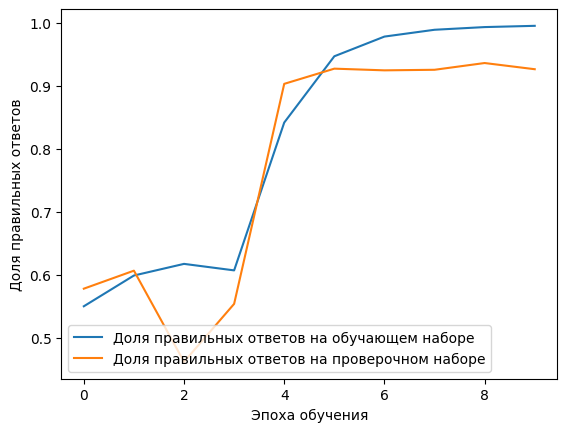

In [55]:
plt.plot(history.history['accuracy'],
         label='Доля правильных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля правильных ответов на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля правильных ответов')
plt.legend()
plt.show()

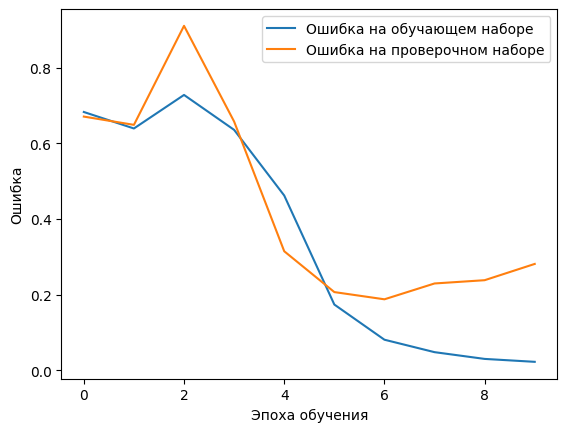

In [56]:
plt.plot(history.history['loss'],
         label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'],
         label='Ошибка на проверочном наборе')
plt.xlabel('Эпоха обучения')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

## Оцениваем качество обучения на тестовом наборе данных

Определяем долю правильных ответов (accuracy) на тестовом наборе данных

In [57]:
score = model.evaluate(x_test, y_test)

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9332 - loss: 0.2443


In [58]:
score

[0.24434511363506317, 0.9332143068313599]

## Применяем модель для определения тональности отзыва на банк

**Позитивный отзыв**

In [41]:
positive_text = """Брал кредит в Мегабанке на автомобиль. Выдали за один день. Никаких скрытых комиссий и переплат.
У банка удобное мобильное приложение, через которое можно быстро отправить ежемесячный платеж.
Досрочное гасить начал через три месяца. Я доволен оперативностью и удобством. Огромное спасибо!
"""

Подготовка текста к обработке

In [42]:
positive_preprocessed_text = preprocess(positive_text, stop_words, punctuation_marks, morph)

In [43]:
positive_preprocessed_text

['брать',
 'кредит',
 'мегабанк',
 'автомобиль',
 'выдать',
 'день',
 'никакой',
 'скрытый',
 'комиссия',
 'переплата',
 'банк',
 'удобный',
 'мобильный',
 'приложение',
 'который',
 'быстро',
 'отправить',
 'ежемесячный',
 'платёж',
 'досрочный',
 'гасить',
 'начать',
 'месяц',
 'довольный',
 'оперативность',
 'удобство',
 'огромный',
 'спасибо']

In [44]:
positive_seq = text_to_sequence(positive_preprocessed_text, word_to_index)

In [45]:
positive_seq

[162,
 9,
 942,
 129,
 6,
 79,
 1866,
 78,
 1007,
 2,
 274,
 292,
 747,
 8,
 122,
 195,
 475,
 31,
 345,
 1399,
 266,
 35,
 286,
 890,
 1293,
 299,
 73]

In [46]:
positive_padded_seq = pad_sequences([positive_seq], maxlen=maxlen, padding='post')

In [47]:
positive_padded_seq

array([[ 162,    9,  942,  129,    6,   79, 1866,   78, 1007,    2,  274,
         292,  747,    8,  122,  195,  475,   31,  345, 1399,  266,   35,
         286,  890, 1293,  299,   73,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

Выполняем распознавание

In [48]:
result = model.predict(positive_padded_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


In [49]:
result

array([[0.9992223]], dtype=float32)

**Негативный отзыв**

In [50]:
negative_text = """Взял кредит в ТакСебеБанке на автомобиль. В договор включили обязательный контракт
на помощь на дороге, который мне не нужен. Узнал об этом только во время подписания договора, иначе бы отказался.
Альтернативы была страхование жизни, но мне это даже не предложили. Скорее всего, менеджер продвигает
продажи услуг этой компании в ущерб интересов клиента. Как минимум, непорядочно и непрофессионально.
У банка ужасное мобильное приложение, из-за которого с меня взяли штраф 10 тыс.руб. По требованиям
банка после покупки автомобиля в приложении нужно загрузить ПТС. Я загрузил и проверил, что ПТС в приложении есть.
Но через некоторое время ПТС из приложения пропал и с меня взяли штраф. Никому не рекомендую связываться с ТакСебеБанком.
"""

In [51]:
negative_preprocessed_text = preprocess(negative_text, stop_words, punctuation_marks, morph)
negative_seq = text_to_sequence(negative_preprocessed_text, word_to_index)
negative_padded_seq = pad_sequences([negative_seq], maxlen=maxlen, padding='post')

In [52]:
negative_padded_seq

array([[ 121,    9,  942,   29, 1262, 1049, 3518,  300, 1146,    8,  143,
         172,    4,   22,  841,   29,  984,  261, 2837,  233,  407,    4,
         124,  920,   21,   82, 7951, 1069,   45,  328, 1918, 1449,   13,
         838, 3150,    2, 1412,  292,  747,  248,    8,  121,  322,  118,
        3603,  438,    2,  189,  942,  747,   93, 4058,  926, 4058,  398,
         926,  747,  319,   22,  926,  747, 1594,  121,  322,  154,  466,
        1114,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0, 

In [53]:
result = model.predict(negative_padded_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [54]:
result

array([[0.04629711]], dtype=float32)